## 基于 Bangumi 评分数据的多维度建模分析


### Data Descirbe
基于从 https://bgm.tv/anime/browser?sort=rank 中通过python爬虫抓取的数据，字段如下：
- `subject_id`：bangumi官网记录番剧数据的时间排序，从1开始
- `name_cn`：番剧的中文名称
- `name`：原名
- `score`：评分（1~10）
- `total`：总评价人数
- `year`：开播时间
- `company`：动漫制作公司
- `rate_i`($1\leq i \leq 10$)：打出i分的人数

该数据中仅包含了bangumi网站中**有评分的数据**（大部分评分人数不足的番剧没有评分，没有记载其中）。基础排序按照**score**高低顺序，一共有**8390**组数据，**year**与**company**中有部分缺失值。

In [ ]:
#Processing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from logger import logger
from statsmodels.noarametric.smoothers_lowess import lowess
from scipy.stats import spearmanr


def get_data():
    try:
        logger.info("Loading Bangumi anime dataset...")
        
        # Read CSV with appropriate handling for mixed types
        df = pd.read_csv(
            "bangumi_anime.csv",
            sep=",",
            engine="c",
            encoding="utf-8",
            dtype={
                'subject_id': 'int64',
                'name_cn': 'str',
                'name': 'str',
                'score': 'float64',
                'total': 'int64',
                'year': 'str',
                'company': 'str',
                'rate_1': 'int64',
                'rate_2': 'int64',
                'rate_3': 'int64',
                'rate_4': 'int64',
                'rate_5': 'int64',
                'rate_6': 'int64',
                'rate_7': 'int64',
                'rate_8': 'int64',
                'rate_9': 'int64',
                'rate_10': 'int64'
            },
            na_values={
                'year': ['', 'NA', 'N/A', 'null', 'NULL', 'None'],
                'company': ['', 'NA', 'N/A', 'null', 'NULL', 'None'],
                'name': ['', 'NA', 'N/A', 'null', 'NULL', 'None']
            },
            keep_default_na=True
        )
        
        logger.info(f"Initial dataset: {df.shape[0]} rows, {df.shape[1]} columns")
        return df
    except Exception as e:
        logger.error(f"Failed to load Bangumi anime dataset: {e}")
        raise

get_data().head()

[23/Dec/2025 00:10:47] INFO - Loading Bangumi anime dataset...
[23/Dec/2025 00:10:47] INFO - Initial dataset: 8390 rows, 17 columns


,subject_id,name_cn,name,score,total,year,company,rate_1,rate_2,rate_3,rate_4,rate_5,rate_6,rate_7,rate_8,rate_9,rate_10
0,326,攻壳机动队 S.A.C. 2nd GIG,攻殻機動隊 S.A.C. 2nd GIG,9.2,9401,2004.0,Production I.G,57,7,11,9,28,85,326,1338,3136,4404
1,876,CLANNAD 〜AFTER STORY〜,CLANNAD 〜AFTER STORY〜,9.1,29136,2008.0,京都アニメーション,150,50,50,82,242,596,1440,3565,7316,15645
2,25961,猫和老鼠,Tom and Jerry,9.1,13171,1940.0,Metro-Goldwyn-Mayer cartoon studio→Rembrandt F...,61,18,13,11,38,194,659,1910,3678,6589
3,253,星际牛仔,カウボーイビバップ,9.1,18324,1998.0,サンライズ,62,14,17,24,100,274,856,2711,5878,8388
4,324,攻壳机动队 STAND ALONE COMPLEX,攻殻機動隊 STAND ALONE COMPLEX,9.1,10728,2002.0,Production I.G,31,7,9,18,50,143,398,1751,3970,4351


---

### Research questions
1. **时间轴分析**：开播年份与评分的关系
2. **“粉黑大战”**：评分分布形态研究
3. **厂牌效应**： 顶级动画公司是否具备持续产出高口碑作品的稳定性？

---

### Data Cleaning & Processing

In [12]:
df=get_data()
df.describe()

[23/Dec/2025 00:10:47] INFO - Loading Bangumi anime dataset...
[23/Dec/2025 00:10:47] INFO - Initial dataset: 8390 rows, 17 columns


,subject_id,score,total,rate_1,rate_2,rate_3,rate_4,rate_5,rate_6,rate_7,rate_8,rate_9,rate_10
count,8390.000000,8390.000000,8390.000000,8390.000000,8390.000000,8390.000000,8390.000000,8390.000000,8390.000000,8390.000000,8390.000000,8390.000000,8390.000000
mean,166441.091895,6.483707,1607.520262,10.144696,8.384982,17.170083,43.537306,111.874732,288.670799,462.242908,419.937783,156.753754,88.803218
std,154127.259075,0.936590,3184.732535,62.693867,35.247247,59.457088,114.824555,201.780220,483.254976,889.046399,1127.544521,684.097056,454.423603
min,8.000000,1.200000,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24827.250000,6.000000,149.000000,0.000000,1.000000,1.000000,4.000000,16.000000,39.000000,37.000000,13.000000,2.000000,3.000000
50%,119060.500000,6.600000,450.000000,2.000000,2.000000,4.000000,12.000000,40.000000,107.000000,118.500000,51.000000,9.000000,8.000000
75%,288235.750000,7.100000,1503.500000,6.000000,6.000000,13.000000,36.000000,115.000000,309.750000,444.000000,243.000000,44.000000,32.750000
max,600890.000000,9.200000,37036.000000,3237.000000,1862.000000,3086.000000,4489.000000,3019.000000,5713.000000,8988.000000,12850.000000,13731.000000,15645.000000


#### Missing Value:
`Year`与`Company`缺失值的处理:\
Missing years and companies filled with `'Unknown'` (string value)

In [13]:
logger.info("Handling missing values...")

# Year: Fill with 'Unknown'
missing_years = df['year'].isna().sum()
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['year'] = df['year'].fillna('Unknown')
logger.info(f"  - Year: Imputed {missing_years} missing values with Unknown")

# Company: Fill with 'Unknown'
missing_companies = df['company'].isna().sum()
df['company'] = df['company'].fillna('Unknown')
logger.info(f"  - Company: Filled {missing_companies} missing values with 'Unknown'")

[23/Dec/2025 00:10:48] INFO - Handling missing values...
[23/Dec/2025 00:10:48] INFO -   - Year: Imputed 125 missing values with Unknown
[23/Dec/2025 00:10:48] INFO -   - Company: Filled 5305 missing values with 'Unknown'


In [14]:
# Show the "Unknown"
df[df['year'] == 'Unknown'][['subject_id', 'name_cn', 'name', 'year', 'company', 'score', 'total']].head(10)

,subject_id,name_cn,name,year,company,score,total
31,1962,大闹天宫,大闹天宫,Unknown,上海美术电影制片厂,8.6,5430
250,47665,鼹鼠的故事,Krtek,Unknown,StudioBratrivtriku,8.0,973
323,334105,剧场版 魔法少女小圆 〈魔女之夜的回天〉,劇場版 魔法少女まどか☆マギカ〈ワルプルギスの廻天〉,Unknown,Unknown,8.0,255
433,751,葫芦兄弟,葫芦兄弟,Unknown,上海美术电影制片厂,7.8,3773
449,501963,无职转生 第三季 ～到了异世界就拿出真本事～,無職転生Ⅲ ～異世界行ったら本気だす～,Unknown,Unknown,7.9,194
528,36186,天书奇谭,天书奇谭,Unknown,Unknown,7.7,1291
587,5870,九色鹿,九色鹿,Unknown,Unknown,7.7,1599
671,14511,莫莫,莫莫,Unknown,漫想族(漫想族文化) 制作,8.1,60
854,35632,小蝌蚪找妈妈,小蝌蚪找妈妈,Unknown,Unknown,7.5,1110
910,109604,牧笛,牧笛,Unknown,Unknown,7.6,198


In [15]:
df[df['company'] == 'Unknown'][['subject_id', 'name_cn', 'name', 'year', 'company', 'score', 'total']].head(10)

,subject_id,name_cn,name,year,company,score,total
5,1728,浪客剑心 追忆篇,るろうに剣心 -明治剣客浪漫譚- 追憶編,1999.0,Unknown,8.9,8930
6,6049,新世纪福音战士剧场版 Air/真心为你,新世紀エヴァンゲリオン劇場版 Air/まごころを、君に,1997.0,Unknown,8.9,20091
11,321,机动警察剧场版2 和平保卫战,機動警察パトレイバー 2 the Movie,1993.0,Unknown,8.8,3706
12,839,蓝色恐惧,PERFECT BLUE,1998.0,Unknown,8.8,10457
15,3375,凉宫春日的消失,涼宮ハルヒの消失,2010.0,Unknown,8.7,22698
17,263750,进击的巨人 第三季 Part.2,進撃の巨人 Season 3 Part.2,2019.0,Unknown,8.7,21117
25,37460,哆啦A梦 大山版,ドラえもん,1979.0,Unknown,8.7,3006
28,1608,灌篮高手,スラムダンク,1993.0,Unknown,8.6,9066
29,67753,明日之丈2,あしたのジョー2,1980.0,Unknown,8.7,786
30,1015,机动战士高达0080 口袋里的战争,機動戦士ガンダム0080 ポケットの中の戦争,1989.0,Unknown,8.6,5464


#### Process Value：
1.计算 **“争议指数 (Controversy Score)”** 

**争议指数**的计算方式如下：\
先明确一个概念 —— `Shannon Entropy`：
- Shannon Entropy（香农熵）由克劳德·香农（Claude Shannon）在1948年提出。它用于量化一个随机变量的不确定性或信息量。简单来说，熵越高，事件的不确定性越大，需要更多信息来描述它；熵越低，不确定性越小。
- 对于一个离散随机变量 $X$，其取值集合为 $\{x_1, x_2, \dots, x_n\}$，每个值出现的概率分别为 $p(x_1), p(x_2), \dots, p(x_n)$（满足 $\sum p(x_i) = 1$），香农熵 $H(X)$ 定义为：

$$H(X) = -\sum_{i=1}^{n} p(x_i) \log p(x_i)$$
- 以频率估计概率，我们就能得到anime的**争议指数**。

In [16]:
logger.info("Engineering features...")

# 1. CONTROVERSY SCORE (Shannon Entropy of Rating Distribution)
rating_cols = ['rate_1', 'rate_2', 'rate_3', 'rate_4', 'rate_5', 
               'rate_6', 'rate_7', 'rate_8', 'rate_9', 'rate_10']

def calculate_controversy_score(row):
    """Calculate Shannon entropy of rating distribution"""
    # Get rating counts
    rating_counts = row[rating_cols].values.astype(float)
    
    # Normalize to probabilities
    total_ratings = rating_counts.sum()
    if total_ratings == 0:
        return 0
    
    probabilities = rating_counts / total_ratings
    
    # Calculate Shannon entropy (base e)
    # Filter out zero probabilities to avoid log(0)
    probabilities = probabilities[probabilities > 0]
    entropy_value = -np.sum(probabilities * np.log(probabilities))
    
    return entropy_value

df['controversy_score'] = df.apply(calculate_controversy_score, axis=1)
logger.info(f"  - Controversy Score: Range {df['controversy_score'].min():.3f} - {df['controversy_score'].max():.3f}")
logger.info(f"    Mean: {df['controversy_score'].mean():.3f}, Std: {df['controversy_score'].std():.3f}")

[23/Dec/2025 00:10:48] INFO - Engineering features...
[23/Dec/2025 00:10:49] INFO -   - Controversy Score: Range 0.366 - 2.178
[23/Dec/2025 00:10:49] INFO -     Mean: 1.554, Std: 0.150


2.计算 **“权重评分”**：通过**贝叶斯加权评分公式**（Bayesian Weighted Rating）对 score 进行加权处理，减少评分偏差，增加可信度。
<br>
<br>

**权重评分**的计算方式如下：
$$WR = \frac{v}{v + m} \cdot R + \frac{m}{v + m} \cdot C$$

其中：

- **WR**（Weighted Rating）：贝叶斯加权后的最终评分。

- **v**：该作品的投票总数（vote count，例如数据中的 `total`）。

- **R**：该作品的平均评分（raw average score，例如数据中的 `score`，通常是1-10分）。

- **m**：最小投票阈值（minimum votes required），一个超参数，用于控制“拉回”力度。通常取所有作品投票数的某个分位点（如中位数或平均值）。

- **C**：所有作品的整体平均评分（global mean score），即整个数据集的平均分。

公式直观解释:

- 当 **v 很大**（投票数很多）时，$(\frac{v}{v+m} \approx 1)$，WR 接近原始平均分 R（信任度高）。

- 当 **v 很小**（投票数很少）时，$(\frac{v}{v+m} \approx 0)$，WR 接近整体平均分 C（不信任小样本评分）。

- 这相当于在原始评分 R 和全局平均 C 之间做加权平均，权重取决于样本量 v 的可靠程度。

In [17]:
# 2. BAYESIAN WEIGHTED SCORE
# Formula: (C * m + total * score) / (C + total)
# where:
#   C = confidence threshold (minimum votes for full weight)
#   m = mean score across all anime (prior belief)
        
# Calculate global mean score (prior belief)
global_mean_score = df['score'].mean()
        
# Set confidence threshold (C parameter)
# Using the 75th percentile of total votes as confidence threshold
confidence_threshold = df['total'].quantile(0.75)
        
logger.info(f"  - Bayesian Weighted Score Parameters:")
logger.info(f"    Global mean score (prior): {global_mean_score:.2f}")
logger.info(f"    Confidence threshold (C): {confidence_threshold:.0f} votes")
        
# Calculate Bayesian weighted score
df['bayesian_score'] = (
    (confidence_threshold * global_mean_score + df['total'] * df['score']) / 
    (confidence_threshold + df['total'])
)
        
logger.info(f"  - Bayesian Weighted Score: Range {df['bayesian_score'].min():.2f} - {df['bayesian_score'].max():.2f}")
logger.info(f"    Mean: {df['bayesian_score'].mean():.2f}, Std: {df['bayesian_score'].std():.2f}")

[23/Dec/2025 00:10:49] INFO -   - Bayesian Weighted Score Parameters:
[23/Dec/2025 00:10:49] INFO -     Global mean score (prior): 6.48
[23/Dec/2025 00:10:49] INFO -     Confidence threshold (C): 1504 votes
[23/Dec/2025 00:10:49] INFO -   - Bayesian Weighted Score: Range 2.88 - 8.97
[23/Dec/2025 00:10:49] INFO -     Mean: 6.57, Std: 0.41


增加`display_name`,方便识别。

In [18]:
df['display_name'] = df['name'].astype(str) + " (" + df['name_cn'].astype(str) + ")"

---

### Data Analysis & Visulizaiton


#### 1. 时间轴分析：跨越时代的评价变迁
**研究目的：** 探讨动画质量随时间的变化趋势，并验证是否存在“老番滤镜”或“现代通胀”。


在探究动画评分随时间变化的趋势时，我们采用了 **Spearman 秩相关系数 ($\rho$)** 而非传统的 Pearson 相关系数。

##### **为什么选择 Spearman？**
*   **非线性关系捕捉：** Pearson 相关系数要求变量之间存在线性关系，而动画评分随年份的变化可能呈现非线性趋势（如波动或阶梯式增长）。Spearman 衡量的是**单调性（Monotonicity）**，只要评分随年份大致上升或下降即可，不要求是直线。
*   **稳健性 (Robustness)：** 动画数据中存在极端高分或低分（离群值），Spearman 基于数据的**秩次（排名）**而非原始数值进行计算，因此对异常值和分布偏态（Skewness）不敏感，更适合评分数据。

Spearman 秩相关系数 $\rho$ 的计算过程如下：
首先将原始数据 $X_i$ (年份) 和 $Y_i$ (评分) 转换为排名 $rg(X_i)$ 和 $rg(Y_i)$。

如果原始数据中没有重复值，公式简化为：
$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$

其中：
*   $d_i = rg(X_i) - rg(Y_i)$ 是每部作品年份排名与评分排名之差。
*   $n$ 是样本总量。

在代码实现中（`scipy.stats.spearmanr`），系统会自动处理重复排名（Tied ranks），计算结果范围在 $[-1, 1]$ 之间：
*   **$\rho > 0$**：正相关，随年份增长评分有上升趋势。
*   **$\rho < 0$**：负相关，随年份增长评分有下降趋势。
*   **$| \rho |$**：越接近 1，相关性越强。

##### **LOWESS (局部加权散点平滑)** 曲线

*   为了增强分析的视觉效果和非参数表达，我们同时引入了 **LOWESS (局部加权散点平滑)** 曲线。**LOWESS**（Locally Weighted Scatterplot Smoothing）是一种非参数平滑方法，通过在每个局部区间内对邻近数据进行加权回归来刻画变量之间的整体变化趋势，不依赖于线性假设，适合用于展示评分随年份变化的趋势结构。

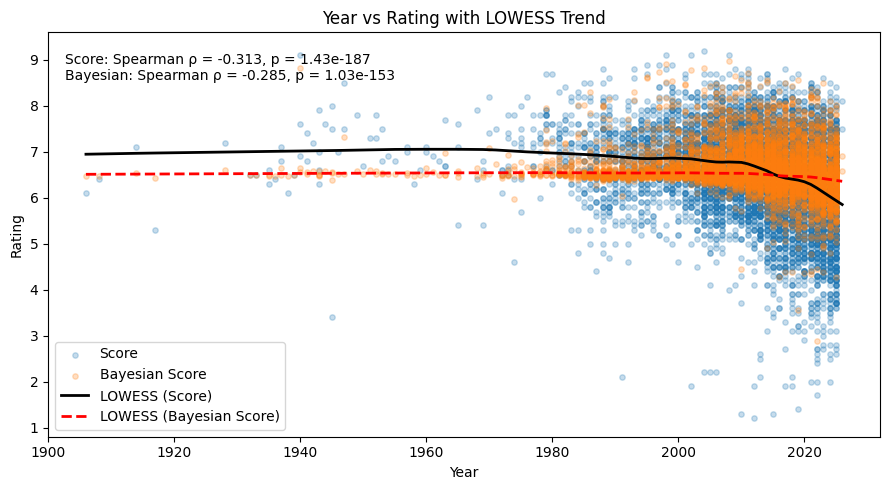

In [19]:
# Copy what we need
yr_df = df[['year', 'score', 'bayesian_score']].copy()

# Delete year = 'Unknown'
yr_df = yr_df[yr_df['year'] != 'Unknown']

rho_score, p_score = spearmanr(yr_df['year'], yr_df['score'])
rho_bayes, p_bayes = spearmanr(yr_df['year'], yr_df['bayesian_score'])

lowess_score = lowess(yr_df['score'], yr_df['year'], frac=0.3)
lowess_bayes = lowess(yr_df['bayesian_score'], yr_df['year'], frac=0.3)

plt.figure(figsize=(9, 5))
plt.scatter(yr_df['year'], yr_df['score'],
            alpha=0.25, s=15, label='Score') # Draw original score
plt.scatter(yr_df['year'], yr_df['bayesian_score'],
            alpha=0.25, s=15, label='Bayesian Score') # Draw Bayesian score
plt.plot(lowess_score[:, 0], lowess_score[:, 1],
         linewidth=2, label='LOWESS (Score)', color="black") # Draw Lowess line of original score
plt.plot(lowess_bayes[:, 0], lowess_bayes[:, 1],
         linewidth=2, linestyle='--', label='LOWESS (Bayesian Score)', color="red") #Draw Lowess line of Bayesian score

plt.xlabel("Year")
plt.ylabel("Rating")
plt.title("Year vs Rating with LOWESS Trend")

plt.text(
    0.02, 0.95,
    f"Score: Spearman ρ = {rho_score:.3f}, p = {p_score:.3g}\n"
    f"Bayesian: Spearman ρ = {rho_bayes:.3f}, p = {p_bayes:.3g}",
    transform=plt.gca().transAxes,
    va='top'
)

plt.legend()
plt.tight_layout()
plt.show()

由散点图看到大部分的数据都汇集在1980-2025年这一时间段，因此我们放大这一区间，继续看差异。

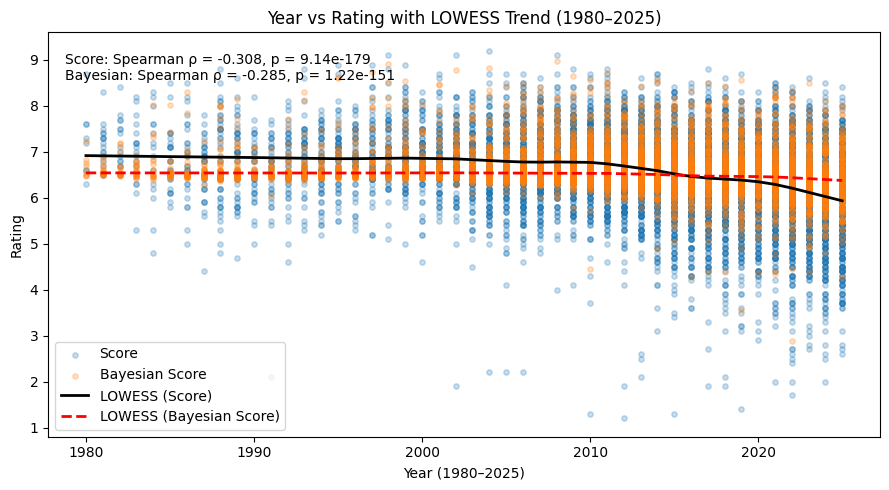

In [20]:
yr_df_zoom = yr_df[(yr_df['year'] >= 1980) & (yr_df['year'] <= 2025)]

rho_s_z, p_s_z = spearmanr(yr_df_zoom['year'], yr_df_zoom['score'])
rho_b_z, p_b_z = spearmanr(yr_df_zoom['year'], yr_df_zoom['bayesian_score'])

lowess_score_z = lowess(yr_df_zoom['score'], yr_df_zoom['year'], frac=0.3)
lowess_bayes_z = lowess(yr_df_zoom['bayesian_score'], yr_df_zoom['year'], frac=0.3)

plt.figure(figsize=(9, 5))
plt.scatter(yr_df_zoom['year'], yr_df_zoom['score'],
            alpha=0.25, s=15, label='Score')
plt.scatter(yr_df_zoom['year'], yr_df_zoom['bayesian_score'],
            alpha=0.25, s=15, label='Bayesian Score')
plt.plot(lowess_score_z[:, 0], lowess_score_z[:, 1],
         linewidth=2, label='LOWESS (Score)', color="black")
plt.plot(lowess_bayes_z[:, 0], lowess_bayes_z[:, 1],
         linewidth=2, linestyle='--', label='LOWESS (Bayesian Score)', color="red")

plt.xlabel("Year (1980–2025)")
plt.ylabel("Rating")
plt.title("Year vs Rating with LOWESS Trend (1980–2025)")

plt.text(
    0.02, 0.95,
    f"Score: Spearman ρ = {rho_s_z:.3f}, p = {p_s_z:.3g}\n"
    f"Bayesian: Spearman ρ = {rho_b_z:.3f}, p = {p_b_z:.3g}",
    transform=plt.gca().transAxes,
    va='top'
)

plt.legend()
plt.tight_layout()
plt.show()


> “通过对比原始评分（Score）与贝叶斯加权评分（Bayesian Score）的 Spearman 相关系数，我们发现：
> 1. **$|\rho_{bayes}| < |\rho_{score}|$**，而$\rho$都为负值，说明动画行业的整体质量确实在下滑，但下滑的剧烈程度被那些“垃圾小众作”夸大了。
> 2. 得到的 $p$ 远小于 **0.05** ，说明这种下降趋势绝非随机偶然，而是数据中真实存在的普遍规律。
> 3. 两张图的 Spearman 相关系数 $\rho$ 均在 **-0.28 到 -0.31** 之间。这是一个显著的负相关。这意味着随着年份的增加，动画的评分呈现出下降趋势。
> 4. 观察 1980 年之前的散点，数据点相对稀疏且大多集中在 **6.0-8.0** 之间，极少有低于 4 分的作品。这反映了**幸存者偏差**。几十年前的平庸作品（甚至是烂作）早已湮灭在历史长河中，没有被收录进数据库，或者没人去评分。能流传至今并被现代观众评分的老番，大多是经过时间筛选的经典之作。2010 年后的散点密密麻麻，且出现了大量 1-4 分的极低分作品。这说明现代动画产量剧增，且所有作品（无论好坏）都会被即时记录，导致平均分被大量平庸作和烂作拉低。
> 5.  原始评分在 2010 年后剧烈下滑，而贝叶斯评分虽然也有下降，但表现平稳（基本维持在 **6.5** 左右）。贝叶斯公式将那些“投票数不足”的作品评分拉向了平均分，从而过滤了小样本噪声。因此动画行业的“核心口碑”其实并没有黑色曲线显示的下滑得那么严重，这种下滑很大程度上是因为“低分低热度”作品的大量增加。这也引出了我们的下一个议题：关于现代那些作品的争议度讨论。

#### 2. “粉黑大战”：争议度的深度解剖
**研究目的：** 找出哪些番剧是真正的“口碑两极分化”，哪些是“全民公认”。

接下来以原始评分的数据，x轴为香农熵（争议指数），y轴为评分，绘制一个争议象限图。

In [21]:
def plot_interactive_quadrant(df):

    fig = px.scatter(
        df, 
        x="controversy_score", 
        y="score",
        hover_name="display_name",
        hover_data={                
            "controversy_score": ":.3f", 
            "score": ":.2f"
        },
        opacity=0.6,
        color="controversy_score",  # color change with controversy score
        color_continuous_scale="Viridis",
        title="Interactive Analysis: Controversy vs. Quality",
        labels={
            "controversy_score": "Controversy Score",
            "score": "Rating"
        }
    )

    # 2. Add Quadrant lines(Using median)
    c_median = df['controversy_score'].median()
    s_median = df['score'].median()

    fig.add_vline(x=c_median, line_dash="dash", line_color="red", annotation_text="Median Controversy")
    fig.add_hline(y=s_median, line_dash="dash", line_color="red", annotation_text="Median Score")

    fig.add_annotation(x=df['controversy_score'].min(), y=8.8, text="Consensus Masterpieces", showarrow=False, font=dict(color="green"))
    fig.add_annotation(x=df['controversy_score'].max(), y=8.8, text="Polarizing Works", showarrow=False, font=dict(color="orange"))

    fig.update_layout(
        template="plotly_white",
        height=700,
        coloraxis_colorbar=dict(title="Controversy")
    )
    
    fig.show()

plot_interactive_quadrant(df)

> 1. 图像左上角（Consensus Masterpieces 区域）几乎是空的。也就是实际上很少有评分超过 8.5 且争议指数低于 1.0 的作品。这说明在动画领域，“极高质量”与“高度共识”很难并存。一部作品得分越高，往往吸引的观众越多，也更容易引发不同立场的讨论（香农熵随之升高）。Bangumi 用户的审美具有很强的个性化，真正的“六边形战士”极难出现。
> 2. 散点图呈现出一个明显的“向右下方倾斜”的趋势，说明“虽然吵得凶但依然能维持超高分”的作品是极少数的案例。

绘制争议度前十五排行榜的条形图，看看那些触发“粉黑大战”作品的案例。

In [22]:
def plot_top_15_polarized(df):
    
    top_15 = df.nlargest(15, 'controversy_score')
    fig = px.bar(
        top_15, 
        x="controversy_score", 
        y="display_name",
        orientation='h',
        color="score", # color respects the level
        color_continuous_scale="Reds",
        title="Top 15 Most Polarized High-Rated Works",
        labels={
            "controversy_score": "Controversy Score (Shannon Entropy)", 
            "display_name": "Anime Name",
            "score": "Score"
        },
        text_auto='.3f' # show the controversy score on the graph
    )

    fig.update_layout(
        yaxis={'categoryorder':'total ascending'}, # Controversy score ranked from highest to lowest
        template="plotly_white",
        height=700
    )
    fig.show()

plot_top_15_polarized(df)

接下来我将在投票数高于5000的作品中（热度相对较高），选取熵值最高和最低的各3部作品，展示它们从1-10分分布曲线的差异。绘制Joyplot（山脊图）来展示评分分布对比。来找到
- *高熵+高分*：神作但有巨大争议。
- *低熵+高分*：口碑极其稳定的神作。
- *高熵+低分*：烂得出奇，但有人洗白（乐子番）。 

In [23]:
def plot_distribution_comparison(df):

    # Choose the top3 and bottom3 controversial anime among the votes >5000
    vt_df = df[df["total"] > 5000]
    top_3 = vt_df.nlargest(3, 'controversy_score')
    bottom_3 = vt_df.nsmallest(3, 'controversy_score')
    targets = pd.concat([top_3, bottom_3])
    targets['group'] = ['High Controversy'] * 3 + ['Low Controversy (Consensus)'] * 3

    targets['full_title'] = (
    targets["display_name"]+"<br>" +
    "Total Votes: " + targets['total'].astype(str) + " | " +
    "Score: " + targets['score'].round(2).astype(str)
    )

    rate_cols = [f'rate_{i}' for i in range(1, 11)]
    
    melted = targets.melt(
        id_vars=['full_title', 'group'], 
        value_vars=rate_cols,
        var_name='rating', 
        value_name='count'
    )
    
    # Convert rate_i to num i
    melted['rating'] = melted['rating'].str.replace('rate_', '').astype(int)

    # Draw Joyplot(with plotly)
    fig = px.area(
        melted, 
        x="rating", 
        y="count", 
        color="group",
        facet_col="full_title", 
        facet_col_wrap=2, # show 2 gragh each line
        title="Rating Distribution: High Controversy vs. High Consensus",
        labels={"count": "Vote Count", "rating": "Rating (1-10)"},
        category_orders={"rating": list(range(1, 11))},
        line_group="full_title"
    )

    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

    fig.update_layout(template="plotly_white", height=900, showlegend=True)
    fig.update_xaxes(tickmode='linear', tick0=1, dtick=1) 
    fig.show()

plot_distribution_comparison(df) 

高质量不再等同于‘无差评’，相反，最具影响力的作品往往是那些能激起最强烈观点对撞的作品。数据告诉我们：平庸导致共识，而卓越往往伴随着争议。

#### 3. 厂牌效应：动画公司的稳定性建模
**研究目的：** 评估动画公司是“神作制造机”还是“质量过山车”。

首先，公司名为`Unknown`（后面会额外分析）以及作品数小于5的公司不参与讨论（缺乏可信度），将数据处理到`company_stats`的dataframe里面。

In [24]:
# 作品数阈值
N = 5

company_stats = (
    df
    .loc[
        (df['company'] != 'Unknown') & 
        (df['bayesian_score'].notna()),
        ['company', 'bayesian_score', 'controversy_score','total']
    ]
    .groupby('company')
    .agg(
        work_count=('bayesian_score', 'count'),
        mean_score=('bayesian_score', 'mean'),
        entropy=('controversy_score', 'mean'),
        total_votes=('total', 'sum')
    )
    .query('work_count >= @N')
    .reset_index()
)

然后，以制作公司贝叶斯评分的均值为X轴，香农熵的均值为Y轴，建立气泡图。其中反转Y轴，使得越高熵越小，作品越稳定。气泡的大小表明评分总数，一定程度上表示了公司厂牌的热度。

In [25]:
fig = px.scatter(
    company_stats,
    x='mean_score',
    y='entropy',
    size='total_votes',
    size_max=40,
    hover_name='company',
    hover_data={
        'work_count': True,
        'mean_score': ':.2f',
        'entropy': ':.2f',
        'total_votes': True
    },
    labels={
        'mean_score': 'Mean Bayesian Score',
        'entropy': 'Mean Shannon Entropy',
        'total_votes': 'Total Votes'
    },
    title='Studio Effect: Average Quality vs Stability'
)

# 反转 Y 轴（越高越稳定 → 越好）
fig.update_yaxes(autorange='reversed')

fig.show()

In [26]:
#以京阿尼为特例，标明出来
fig.add_annotation(
    x=company_stats.loc[company_stats['company'] == '京都アニメーション', 'mean_score'].values[0],
    y=company_stats.loc[company_stats['company'] == '京都アニメーション', 'entropy'].values[0],
    text="京都アニメーション",
    showarrow=True,
    arrowhead=2
)

fig.show()

对于将制作公司分为两组"Unknown"与"Known"，看看是否"Unknown"的作品的熵值是否普遍更高？（因为缺乏厂牌背书，评价更随机）。

In [27]:
unknown_entropy = df.loc[df['company'] == 'Unknown', 'controversy_score'].dropna()
known_entropy = df.loc[df['company'] != 'Unknown', 'controversy_score'].dropna()

unknown_entropy.mean(), known_entropy.mean()

(np.float64(1.5490854742689328), np.float64(1.5631310207609896))

Known组香农熵的均值略微高于Unknown组，但差距不是很大，这说明了在小程度上Unknown的制作公司制作出来的作品争议度小一点。

下面继续绘制Known Studio 与Unknown Studio两组的box plot 和violin plot的对比，继续看差异。

In [28]:
viz_df = df.loc[
    df['controversy_score'].notna(),
    ['company', 'controversy_score']
].assign(
    company_type=lambda x: x['company'].apply(
        lambda c: 'Unknown' if c == 'Unknown' else 'Known'
    )
)

fig = px.violin(
    viz_df,
    x='company_type',
    y='controversy_score',
    box=True,
    points='all',
    color='company_type',
    title='Entropy Distribution: Unknown vs Known Studios'
)

fig.update_layout(
    xaxis_title='Studio Type',
    yaxis_title='Shannon Entropy of Ratings',
    showlegend=False
)

fig.show()


两张图几乎处于同一水平，这也表明了公司的知名度并不会从根本上改变作品争议度的平均水平。
接下来不妨再以京阿尼的作品与Unknown的作品进行比较，看看具体的优异之处。

In [29]:
kyoto_name = '京都アニメーション' 

kyoto_df = df.loc[
    (df['controversy_score'].notna()) & 
    (df['company'].isin([kyoto_name, 'Unknown'])), # assign reserving
    ['company', 'controversy_score']
].assign(
    company_type=lambda x: x['company'].apply(
        lambda c: 'Kyoto Animation' if c == kyoto_name else 'Unknown Studio'
    )
)

# 3. 绘图
fig = px.violin(
    kyoto_df,
    x='company_type',
    y='controversy_score',
    box=True,
    points='all',       
    color='company_type',
    color_discrete_map={'Kyoto Animation': '#1f77b4', 'Unknown': '#ff7f0e'}, 
    title='Entropy Distribution: Kyoto Animation vs. Unknown Studios'
)

fig.update_layout(
    xaxis_title='Studio Group',
    yaxis_title='Shannon Entropy (Controversy)',
    showlegend=False,
    template="plotly_white"
)

fig.show()

京阿尼（Kyoto Animation）的箱线图（Box）比未知公司更紧凑，且底部边缘（Lower Whisker）明显高于未知公司。京阿尼的作品熵值几乎没有低于 1.0 的。京阿尼的小提琴图在顶部（熵值约 2.2 处）有一个显著的凸起（Bulge）。而未知公司在同一高度的分布则非常纤细。这说明顶级厂牌更容易造成现象级争议。 尽管两组背景迥异，但它们的中位数（Median）几乎完全重合（都在 1.5 附近），厂牌效应也难以消除观众们审美的固有分歧。 京阿尼的图表告诉我们，成名意味着你永远避不开争议，甚至会创造出比普通作品更剧烈的争议。 这种高质量与高争议的并存，正是顶级动画厂牌生命力的体现。

在对比不同公司或年份时，可以做个 **T-检验** 或 **方差分析 (ANOVA)**，证明“京都动画”的均分确实显著高于“Unknown”。